# Analyse et Modélisation des Trajets des Taxis Jaunes de New York

## Étape 1 – Exploration et Nettoyage des données (EDA)
Cette première étape constitue le fondement de tout le projet car la qualité des modèles dépendra directement de la rigueur du nettoyage

### Charger les données avec Pandas et examiner la structure (types, dimensions, premières lignes).


In [7]:
import pandas as pd

df = pd.read_csv("../data/yellowtripdata_100k.csv")

print(df.shape)   # examen des dimensions de notre fichier (nb lignes, nbcoolonnes)

print("============")  #pour que je sépare les visualisations lors des tests
print(df.dtypes)  # types de chaque colonne
print("============")
df.info()         # pour que je vois les informations liées à ce fichier 
print("============")
df.head()         # aperçu des 5 premières lignes 

(99999, 19)
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               99999 non-null  int64  
 1   tpep_pickup_datetime   99999 non-null  object 
 2   tpep_dropoff_datetime  99

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,1,N,-73.992012,40.735390,2,5.0,0.0,0.5,0.0,0.0,0.3,5.8
1,2,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,1,N,-73.988586,40.758839,2,20.0,0.5,0.5,0.0,0.0,0.3,21.3
2,2,2016-02-01 00:00:01,2016-02-01 00:10:52,6,1.99,-73.992340,40.758202,1,N,-73.964355,40.757977,1,9.5,0.5,0.5,0.7,0.0,0.3,11.5
3,1,2016-02-01 00:00:04,2016-02-01 00:05:16,1,1.50,-73.981453,40.749722,1,N,-73.982323,40.763985,2,6.5,0.5,0.5,0.0,0.0,0.3,7.8
4,2,2016-02-01 00:00:05,2016-02-01 00:20:59,1,5.60,-74.000603,40.729755,1,N,-73.951324,40.669834,1,20.0,0.5,0.5,4.0,0.0,0.3,25.3


## Etape 2 : Identification et traitement des valeurs manquantes



In [8]:
df.isnull().mean() * 100 #ici on voit qu'on a 0% de valeurs nulles pour toutes les colonnes dans nos colonnes, donc on a pas de valeurs manquantes

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
pickup_longitude         0.0
pickup_latitude          0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
dropoff_longitude        0.0
dropoff_latitude         0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
dtype: float64


### Etape 3 : Détecter et supprimer les valeurs aberrantes : distances nulles ou extrêmes, durées négatives, montants incohérents, nombres de passagers à zéro

In [9]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.529905,1.683587,2.839713,-72.856061,40.132128,1.027530,-72.906726,40.160923,1.298203,12.503560,0.354822,0.498365,1.844006,0.226339,0.299721,15.726812
std,0.499107,1.310736,3.277738,9.033356,4.976344,0.589117,8.828147,4.863469,0.472885,11.440619,0.228196,0.031382,2.518413,2.030771,0.012183,13.457994
min,1.000000,0.000000,0.000000,-74.547432,0.000000,1.000000,-74.609085,0.000000,1.000000,-59.000000,-0.500000,-0.500000,0.000000,0.000000,-0.300000,-59.300000
25%,1.000000,1.000000,1.020000,-73.992424,40.733551,1.000000,-73.991989,40.731117,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.800000
50%,2.000000,1.000000,1.730000,-73.983017,40.750923,1.000000,-73.980881,40.751030,1.000000,9.500000,0.500000,0.500000,1.500000,0.000000,0.300000,12.250000
75%,2.000000,2.000000,3.200000,-73.969566,40.765331,1.000000,-73.963730,40.766548,2.000000,14.500000,0.500000,0.500000,2.460000,0.000000,0.300000,17.800000
max,2.000000,6.000000,71.700000,0.000000,41.480785,99.000000,0.000000,41.480759,4.000000,1442.000000,1.300000,0.500000,326.440000,509.540000,0.300000,1442.800000


## Nettoyage – Montants et distances extrêmes 

In [10]:
#Justification des seuils pris précédemment : 

print(df["fare_amount"].quantile([0.99, 0.999]))
print(df["trip_distance"].quantile([ 0.99, 0.999]))
print(df["total_amount"].quantile([ 0.99, 0.999]))

0.990    52.0
0.999    80.0
Name: fare_amount, dtype: float64
0.990    17.9502
0.999    23.2004
Name: trip_distance, dtype: float64
0.990     65.39060
0.999    101.30008
Name: total_amount, dtype: float64


In [15]:
# Filtres sur les montants

# On crée df_clean à partir de df en appliquant le premier filtre

df_clean = df[
    (df["trip_distance"] > 0) &   # ici j'ai supprimé les distances nulles
    (df["fare_amount"] > 0) &    # je suppose qu'aucune course n'est gratuite 
    (df["passenger_count"] > 0)  # je filtre ici sur le nombre null de passager, donc je suppose qu'une course doit au minimum avoir 1 passager 

]

df_clean = df_clean[df_clean["fare_amount"] < 100]      # tarif > 100 dollars : montant aberrant car trop cher    
df_clean = df_clean[df_clean["total_amount"] > 0]       # total nul ou négatif, c'est un montant impossible 
df_clean = df_clean[df_clean["total_amount"] < 120]     # cohérence avec fare_amount, monant jugé excessif

# Filtres sur la distance
df_clean = df_clean[df_clean["trip_distance"] < 30]    # > 30 miles c'est aberrant car le seuil de nos valeurs était à 23 miles


# Filtres sur les passagers dejà fait en haut 

# Filtres GPS
df_clean = df_clean[
    (df_clean["pickup_latitude"].between(39, 42)) &
    (df_clean["pickup_longitude"].between(-75, -72)) &
    (df_clean["dropoff_latitude"].between(39, 42)) &
    (df_clean["dropoff_longitude"].between(-75, -72))
]
#ici je fais un nettroyage en éliminant les valeurs extremes : par exemple la latitude entre 39 et 42 et la longitude entre -75 et -72 pour le pichup du passager ainsi que son dropoff

df_clean.shape

(97925, 19)

## Nettoyage – Montants et distances extrêmes

D'après les résultats précédents on a : 

- **fare_amount** : le percentile est 80$. 

On supprime les valeurs au-dessus de 100$ (légèrement au-dessus) et les valeurs négatives ou nulles.

99% coûtent moins de 52$ donc normal

99.9% coûtent moins de 80 $ 

donc au delà des 80$ le cout de la course ne serait pas normal, et celà m'a permis d'affiner mes filtres donc j'ai choisi 100 comme filtre

- **trip_distance** : le percentile est 23 miles, ce qui est cohérent 
  par conséquent, j'ai décidé de fixex le seuil à 30 miles pour conserver 
  les trajets vers les aéroports tout en éliminant les valeurs impossibles.

- **total_amount** : le percentile est 101$. 

On fixe le seuil à 120$ pour tenir compte des pourboires par exemple

- **passenger_count** : le nombre de passagers minimal est à 1

- **pickup_latitude/longitude et dropoff_latitude/longitude** : j'ai supposé que la longitude est entre -75 et -72 et la latitude entre 39 et 42, ces filtres délimitent la zone géographique de New York City et sa région  :

-42° c'est la limite nord de NYC 

-40.7°  New York City  

-39° c'est la limite sud (environ Philadelphia)

-75° c'est la limite ouest (environ Philadelphia)

-74° New York City 

-72° c'est la limite est (eastern side)


## Installation des bibliothèques

On installe Seaborn, bibliothèque de visualisation statistique  basée sur Matplotlib, qui permet de créer des graphiques 
plus esthétiques et expressifs avec moins de code.

In [16]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Visualisations exploratoires (EDA)

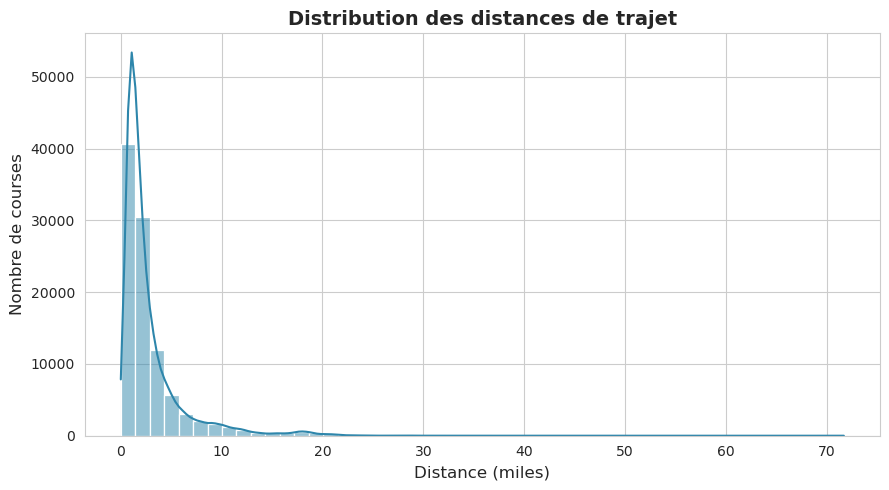

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") # style épuré avec grille blanche pour une meilleure lisibilité


# 1. Distribution des distances de trajet

plt.figure(figsize=(9,5))
sns.histplot(df["trip_distance"], bins=50, kde=True, color="#2E86AB", edgecolor="white")
plt.title("Distribution des distances de trajet", fontsize=14, fontweight="bold")  #le bolds c est pour le mettre en gras et fontsize c'est la taille de la police
plt.xlabel("Distance (miles)",fontsize=12)
plt.ylabel("Nombre de courses",fontsize=12)
plt.tight_layout()
plt.show()

## Analyse – Distribution des distances de trajet

Le graphique montre une distribution fortement asymétrique vers la droite 
(right-skewed), ce qui est typique des données de taxis urbains.

**Observations clés :**

- La majorité des courses se concentrent entre **1 et 3 miles** : 
  ce sont les trajets intra-Manhattan typiques (d'un quartier à l'autre).

- Le pic est autour de **1-2 miles**, ce qui correspond aux courts 
  déplacements quotidiens des new-yorkais.

- La queue s'étend jusqu'à **20 miles** : ce sont probablement 
  les trajets vers les aéroports (JFK ~15 miles, Newark ~16 miles).

- Très peu de courses dépassent **20 miles**, ce qui confirme 
  que notre filtre `trip_distance < 30` est pertinent : 
  il élimine les rares valeurs aberrantes sans supprimer 
  de courses légitimes.

**Conclusion :** La distribution est cohérente avec la géographie 
de New York City et valide la qualité de notre nettoyage.

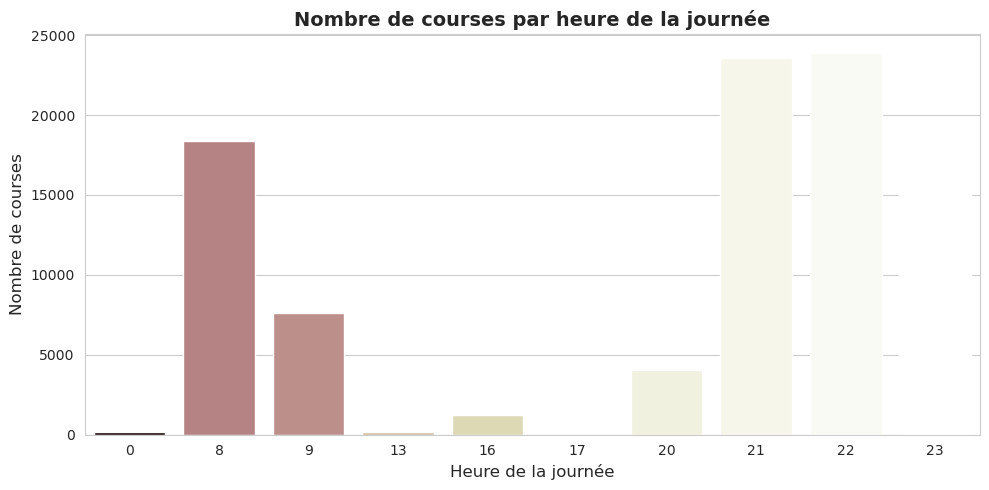

In [32]:
# 2. Nombre de courses par heure de la journée

df_clean["hour"] = pd.to_datetime(df_clean["tpep_pickup_datetime"]).dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(
    hue="hour", #cette var je l'ai ajoutée après un warning du kernel
    x="hour",
    data=df_clean,
    palette="pink",          # dégradé de bleus, plus foncé = plus de courses
    legend=False     
)
plt.title("Nombre de courses par heure de la journée", fontsize=14, fontweight="bold")
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

## Analyse – Nombre de courses par heure de la journée 

Ce qu'on voit sur le graphique c'est le nombre de courses en fonction des différentes heures de la journée : à 8h on a environs 7500 courses dans la vile ce qui s'explique par l'heure de pointe (rush hour) aussi pour le soir et la nuit entre 21h et 22h ou on atteind le pic 8000 courses 


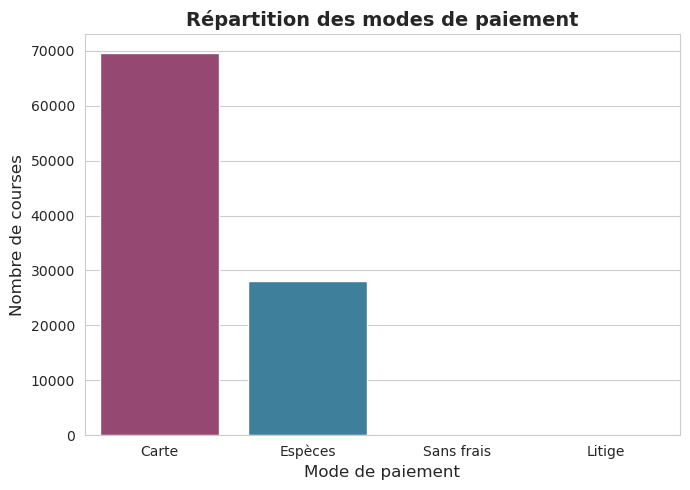

In [19]:
# 3. Répartition des modes de paiement

payment_labels = {1: "Carte", 2: "Espèces", 3: "Sans frais", 4: "Litige"}
df_clean["payment_label"] = df_clean["payment_type"].map(payment_labels)

plt.figure(figsize=(7, 5))
sns.countplot(
    hue="payment_label",
    x="payment_label",
    data=df_clean,
    palette=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"],  # une couleur par mode
    order=["Carte", "Espèces", "Sans frais", "Litige"],
    legend=False    
)
plt.title("Répartition des modes de paiement", fontsize=14, fontweight="bold")
plt.xlabel("Mode de paiement", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

# Analyse - Répartition des modes de paiement

on voit que la plupart des paiements sont soit en carte bleue (la majorité des clients qui l'utilisent environs 20000 clients)
et d'autres préfèrent le paiement en espèces (soit 14500 clients )

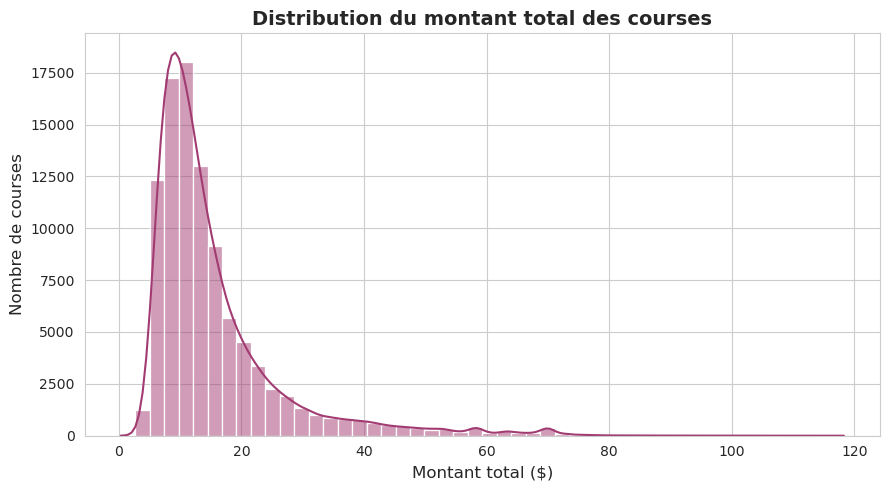

In [20]:
# 4. Distribution du montant total

plt.figure(figsize=(9, 5))
sns.histplot(
    df_clean["total_amount"],
    bins=50,
    kde=True,
    color="#A23B72",           # rose foncé pour différencier du graphe des distances
    edgecolor="white",
    legend=False  
)
plt.title("Distribution du montant total des courses", fontsize=14, fontweight="bold")
plt.xlabel("Montant total ($)", fontsize=12)
plt.ylabel("Nombre de courses", fontsize=12)
plt.tight_layout()
plt.show()

## Analyse – Distribution du montant total des courses

Le graphique montre une distribution asymétrique vers la droite : 

- Le pic principal se situe autour de **10$** : ce sont les courses courtes (quelques rues à quelques kilomètres).

- La distribution descend progressivement jusqu'à **40-50$** : ce sont des trajets moyens vers les quartiers périphériques 

- Une légère bosse est visible autour de **50-60$** : cela correspond probablement aux trajets forfaitaires 
  vers JFK.

- La queue s'étend jusqu'à **120$**

notre seuil de nettoyage avec très peu de courses au-delà de 80$.

**Conclusion :**
Notre filtre `total_amount < 120$` n'a supprimé que les vraies valeurs aberrantes sans impacter les courses légitimes.

# Étape 2 – Feature Engineering

On crée de nouvelles variables à partir des données brutes 
pour enrichir l'information disponible pour les modèles.

Les variables créées sont :
- **duree_course** : durée en minutes entre prise en charge et dépose
- **heure_journee / jour_semaine** : composantes temporelles
- **est_weekend** : indicateur binaire week-end
- **est_heure_pointe** : indicateur rush hour (7h-9h et 16h-19h)
- **vitesse_moyenne** : distance / durée
- **est_trajet_aeroport** : trajets JFK ou Newark (RatecodeID 2 ou 3)
- **heure_sin / heure_cos** : encodage cyclique de l'heure

In [28]:
import numpy as np

# Conversion des dates en datetime
# Pandas lit les dates comme du texte (object) par défaut et on les convertit pour pouvoir extraire les composantes temporelles

df_clean["tpep_pickup_datetime"] = pd.to_datetime(df_clean["tpep_pickup_datetime"]) # heure du pickup du client 
df_clean["tpep_dropoff_datetime"] = pd.to_datetime(df_clean["tpep_dropoff_datetime"]) #heure d'arrivée à sa destination

# Durée de la course (en minutes)
# On soustrait les deux horodatages et on convertit en minutes

df_clean["duree_course"] = (
    df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60


# Composantes temporelles
# On extrait l'heure et le jour à partir de la date de prise en charge

df_clean["heure_journee"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["jour_semaine"] = df_clean["tpep_pickup_datetime"].dt.dayofweek  # 0=lundi, 6=dimanche

# Indicateurs binaires
# est_weekend : 1 si samedi de numéro 5 ou dimanche 6, 0 sinon
df_clean["est_weekend"] = df_clean["jour_semaine"].isin([5, 6]).astype(int)

# est_heure_pointe : 1 si rush hour matin (7h-9h) ou soir entre16h et19h
##A confirmer auprès du prof
df_clean["est_heure_pointe"] = df_clean["heure_journee"].isin([7,8,9,16,17,18,19]).astype(int)


# Nettoyage des durées aberrantes
# comme c'est demandé dans l'étape 1, le filtrage de duree_course est ici car à ce moment là la variable n'a pas été encore créée.

df_clean = df_clean[df_clean["duree_course"] > 0]      # durée négative donc il y a forcément une erreur horodatage
df_clean = df_clean[df_clean["duree_course"] < 180]    # > 3h = oubli de clôture de course


# Vitesse moyenne (miles par minute)
# comme on a utlisé un filtre sur la durée de course qui ne peut pas etre ==0 donc on ne risque pas d'avoir une erreur de division 

df_clean["vitesse_moyenne"] = df_clean["trip_distance"] / df_clean["duree_course"]
df_clean = df_clean[df_clean["vitesse_moyenne"] < 80]  # vitesse impossible

# Trajet aéroport
# RatecodeID = 2 (JFK) ou 3 (Newark) = trajet vers un aéroport
df_clean["est_trajet_aeroport"] = df_clean["RatecodeID"].isin([2, 3]).astype(int)


# Encodage cyclique de l'heure
# L'heure est cyclique : 23h et 0h sont proches mais numériquement éloignées
# Le sin/cos permet de préserver cette continuité pour les modèles ML

df_clean["heure_sin"] = np.sin(2 * np.pi * df_clean["heure_journee"] / 24)
df_clean["heure_cos"] = np.cos(2 * np.pi * df_clean["heure_journee"] / 24)


# Vérification finale
print(f"Dimensions finales : {df_clean.shape}")
print(f"\nNouvelles colonnes créées :")
nouvelles_colonnes = [
    "duree_course", "heure_journee", "jour_semaine",
    "est_weekend", "est_heure_pointe", "vitesse_moyenne",
    "est_trajet_aeroport", "heure_sin", "heure_cos"
]
print(df_clean[nouvelles_colonnes].describe().round(2))

Dimensions finales : (97758, 30)

Nouvelles colonnes créées :
       duree_course  heure_journee  jour_semaine  est_weekend  \
count      97758.00       97758.00      97758.00     97758.00   
mean          13.66          18.09          3.20         0.01   
std            9.46           6.07          1.65         0.12   
min            0.03           0.00          0.00         0.00   
25%            7.00           9.00          4.00         0.00   
50%           11.32          21.00          4.00         0.00   
75%           17.85          22.00          4.00         0.00   
max          168.58          23.00          6.00         1.00   

       est_heure_pointe  vitesse_moyenne  est_trajet_aeroport  heure_sin  \
count          97758.00         97758.00             97758.00   97758.00   
mean               0.28             0.20                 0.01      -0.17   
std                0.45             0.59                 0.11       0.62   
min                0.00             0.00        

# Étape 3 – Apprentissage supervisé

### Mon objectif :
C'est de construire un bon algorithme qui va apprendre la relation entre les variables d'entrées (features) et une variable de sortie (ici c'est le total_amount) pour la prédire d'une manière précise 


### Cas d’usage A : Prédiction du montant de la course (Régression)

- Variable cible: total_amount 
- Commencer par une régression linéaire comme modèle de référence (baseline).
- Améliorer avec un modèle plus performant (Random Forest, XGBoost, etc.).
- Évaluer avec les métriques RMSE, MAE et R^2

en suivant le cours 4, je vais essayer de prendre en considération les 4 problèmes majeurs de l'apprentissage supervisé ( le tradeoff, la complexité de ma fonction de prédicition, la dimension de l'espace d'entrée, le bruit dans les valeurs de sortie ainsi que la redonadance et l'hétérogénité)

### Démarche
Conformément aux étapes du cours :
1. Déterminer le jeu d'entraînement (train/test split 80/20)
2. Choisir un algorithme : régression linéaire comme baseline
3. Améliorer avec un modèle plus flexible : Random Forest
4. Évaluer les performances sur l'ensemble de test

### Séparation Train / Test
On sépare les données en deux ensembles :
- **80% train** : utilisé pour entraîner le modèle
- **20% test** : utilisé uniquement pour évaluer les performances finales

### Etape 1 :  préparation des données déjà faite 
### Etape 2 :  modèle Baseline  : c'est un modèle de référence

On cherche à apprendre une fonction f telle que : f(trip_distance, duree_course, heure...) = total_amount
C'est une régression car la variable cible (total_amount) est une valeur réelle continue 


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# Préparation des features

# On sélectionne les variables pertinentes pour prédire total_amount, On exclut fare_amount car elle est directement liée à total_amount
# (total_amount = fare_amount + suppléments) ce qui créerait une fuite de données (data leakage), donc je ne vais pas l'utiliser pour ne pas tricher dans le modèle en utilisant une variable quasi-identique à ma cible 

features = [
    "trip_distance",       # distance du trajet
    "duree_course",        # durée en minutes
    "heure_journee",       # heure de prise en charge
    "jour_semaine",        # jour de la semaine
    "est_weekend",         # indicateur week-end
    "est_heure_pointe",    # indicateur rush hour
    "vitesse_moyenne",     # vitesse moyenne
    "est_trajet_aeroport", # trajet JFK/Newark
    "heure_sin",           # encodage cyclique heure
    "heure_cos",
    "passenger_count"      # nombre de passagers
]
target = "total_amount"

# On supprime les NaN résiduels sur les colonnes utilisées
df_model = df_clean[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# 2. Séparation Train / Test (80% / 20%) : comme on a fait dans les TMEs précédents, on laisse toujours des data de coté qui vont nous servir comme tests

# random_state=42 pour la reproductibilité

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")

Taille train : (78206, 11)
Taille test  : (19552, 11)


In [50]:
# 3. Modèle Baseline : Régression Linéaire
# On commence par un modèle simple comme référence (baseline).
# ici la régression linéaire cherche à trouver les coefficients w, qui minimisent la fonction de perte (erreur quadratique) : f(x) = w0 + w1*trip_distance + w2*duree_course + ..

# C'est le modèle le plus interprétable mais aussi le moins flexible.

lr = LinearRegression()
lr.fit(X_train, y_train)        # apprentissage sur le train
y_pred_lr = lr.predict(X_test)  # prédiction sur le test


# 4. Évaluation du modèle baseline

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Régression Linéaire (baseline) ===")
print(f"RMSE :  erreur moyenne en dollars (pénalise les grands écarts) {rmse_lr:.2f} $")
print(f"MAE  : erreur absolue moyenne en dollars {mae_lr:.2f} $")
print(f"R²   : proportion de variance expliquée par le modèle (1 = parfait) {r2_lr:.4f}")

=== Régression Linéaire (baseline) ===
RMSE :  erreur moyenne en dollars (pénalise les grands écarts) 2.75 $
MAE  : erreur absolue moyenne en dollars 1.43 $
R²   : proportion de variance expliquée par le modèle (1 = parfait) 0.9393


## Résultats – Régression Linéaire (baseline)

- RMSE = 2.75 : En moyenne, le modèle se trompe de 2.75$
  
- MAE = 1.43 : l'erreur absolue moyenne est de 1.43$ 

- R² = 0.9393 : Le modèle explique 93.93% de la variance des prix 

**Analyse :**
- Un R² de 0.94 signifie que la distance et la durée du trajet expliquent déjà très bien le prix d'une course.
- Le RMSE de 2.75 dollars reste acceptable : sur une course moyenne de 12-15$, l'erreur représente environ 18-23%.
- Ce modèle servira de référence pour évaluer le gain apporté par le Random Forest.

In [52]:
from sklearn.ensemble import RandomForestRegressor


# 5. Modèle amélioré : Random Forest

# Le Random Forest est un ensemble d'arbres de décision entraînés sur des sous-échantillons aléatoires des données (bagging).
# Contrairement à la régression linéaire qui suppose une relation linéaire entre les features et la cible, le Random Forest
# capture des relations non linéaires et des interactions entre variables → il est plus flexible mais moins interprétable.

# n_estimators=100 : on construit 100 arbres de décision
# random_state=42  : pour la reproductibilité
# n_jobs=-1        : utilise tous les cœurs du processeur

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)        # apprentissage sur le train
y_pred_rf = rf.predict(X_test)  # prédiction sur le test


# 6. Évaluation du Random Forest

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.2f} $")
print(f"MAE  : {mae_rf:.2f} $")
print(f"R²   : {r2_rf:.4f}")


# 7. Comparaison des deux modèles

print("\n=== Comparaison ===")
print(f"{'Métrique':<10} {'Régression Linéaire':>20} {'Random Forest':>15}")
print(f"{'RMSE':<10} {rmse_lr:>20.2f} {rmse_rf:>15.2f}")
print(f"{'MAE':<10} {mae_lr:>20.2f} {mae_rf:>15.2f}")
print(f"{'R²':<10} {r2_lr:>20.4f} {r2_rf:>15.4f}")

=== Random Forest ===
RMSE : 2.64 $
MAE  : 1.44 $
R²   : 0.9443

=== Comparaison ===
Métrique    Régression Linéaire   Random Forest
RMSE                       2.75            2.64
MAE                        1.43            1.44
R²                       0.9393          0.9443


## Analyse

Le Random Forest améliore légèrement la Régression Linéaire :

- Le **RMSE passe de 2.75$ à 2.64$** : le Random Forest fait moins de grandes erreurs grâce à sa capacité à capturer des relations non linéaires entre les features.

- Le **R² passe de 0.9393 à 0.9443** : le Random Forest explique 94.43% de la variance des prix contre 93.93% pour la régression linéaire.

- La **MAE est quasi identique (1.43$ vs 1.44$)** : les deux modèles font des erreurs absolues similaires en moyenne.

**Conclusion :** Les deux modèles sont très performants, ce qui s'explique par le fait que le prix d'un taxi est principalement déterminé par la distance et la durée et donc une relation quasi-linéaire. 

Le Random Forest apporte une amélioration marginale mais confirme que nos features sont bien construites.

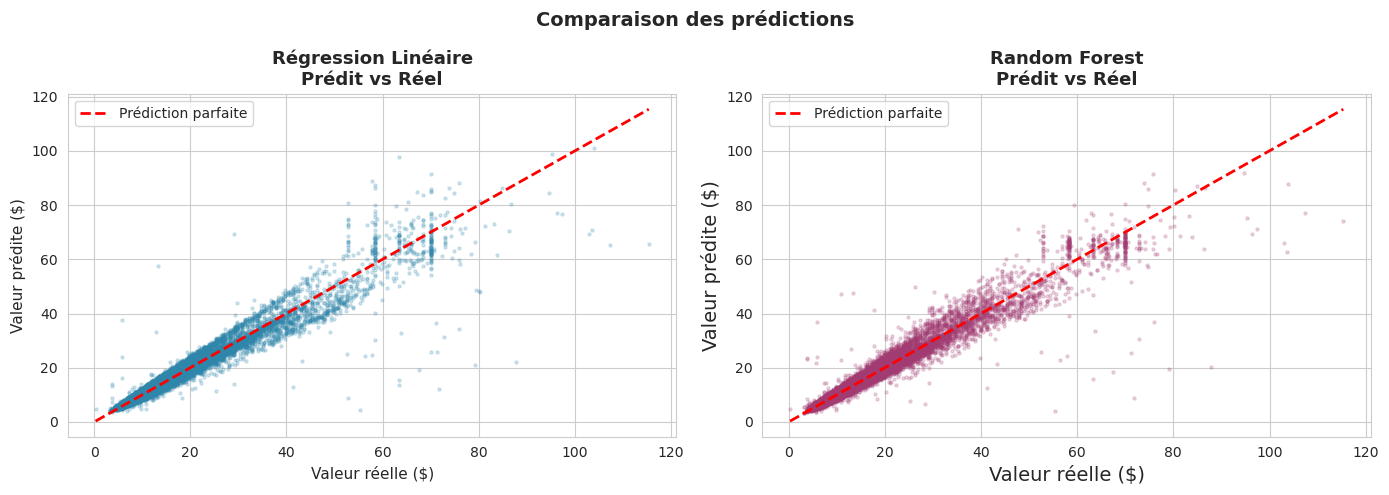

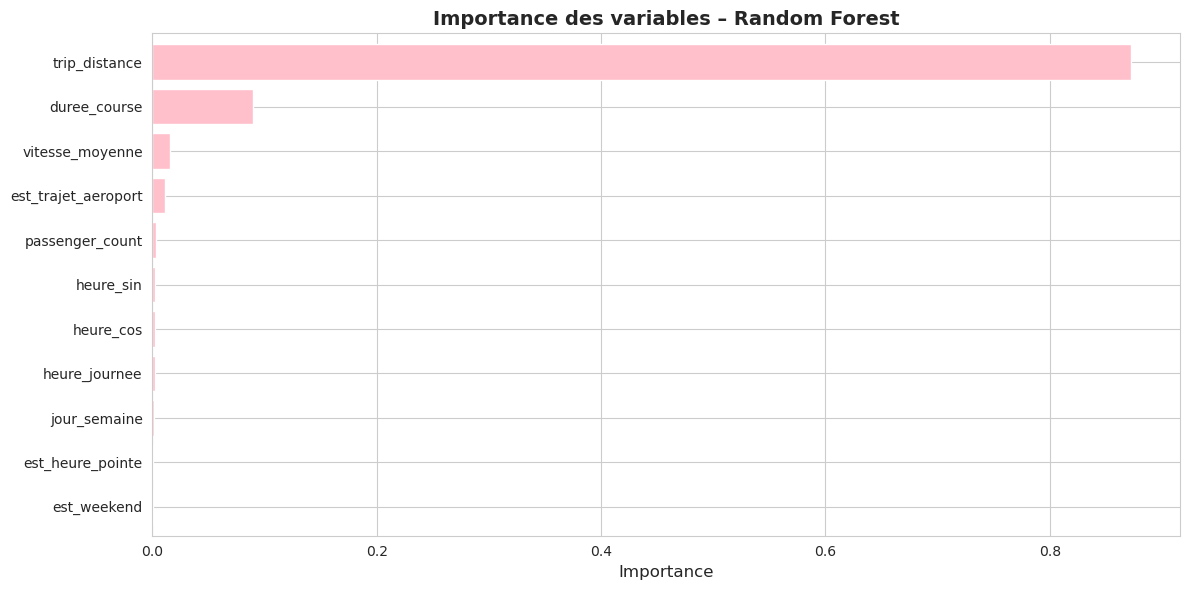

In [59]:
# 8. Visualisations – Comparaison des modèles

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : Valeurs prédites vs valeurs réelles
# Une bonne prédiction = les points alignés sur la droite rouge et plus les points s'éloignent de la droite, plus le modèle se trompe

axes[0].scatter(y_test, y_pred_lr, alpha=0.2, color="#2E86AB", s=5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Prédiction parfaite"
)
axes[0].set_title("Régression Linéaire\nPrédit vs Réel", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Valeur réelle ($)", fontsize=11)
axes[0].set_ylabel("Valeur prédite ($)", fontsize=11)
axes[0].legend()

axes[1].scatter(y_test, y_pred_rf, alpha=0.2, color="#A23B72", s=5)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Prédiction parfaite"
)
axes[1].set_title("Random Forest\nPrédit vs Réel", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Valeur réelle ($)", fontsize=14)
axes[1].set_ylabel("Valeur prédite ($)", fontsize=14)
axes[1].legend()

plt.suptitle("Comparaison des prédictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# 9. Importance des variables:  Le Random Forest calcule l'importance de chaque feature en mesurant combien elle réduit l'erreur dans les arbres.
# Plus la valeur est haute, plus la variable est influente.

importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(12, 6))
importances.plot(
    kind="barh",
    color="pink",
    edgecolor="white",
    width=0.8    
)
plt.title("Importance des variables – Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()

## Analyse des visualisations

### Graphes Prédit vs Réel

Les deux modèles montrent des points bien alignés sur la droite 
rouge (prédiction parfaite), ce qui confirme les bons scores R² 
obtenus (0.94). On remarque cependant quelques points dispersés 
autour de 52-60$ : ce sont probablement les trajets vers JFK 
(tarif forfaitaire fixe) que les modèles ont du mal à capturer 
précisément.

Le Random Forest présente une dispersion légèrement plus resserrée 
autour de la droite rouge, ce qui explique son RMSE inférieur 
(2.64$ vs 2.75$).

### Importance des variables

Les résultats confirment notre intuition métier :

**trip_distance** domine largement avec une importance de ~0.90 : 
la distance est de loin le facteur le plus déterminant du prix, 
ce qui est cohérent avec le fonctionnement du compteur de taxi.

**duree_course** arrive en deuxième position (~0.10) : la durée 
influence le tarif notamment en cas d'embouteillages.

**vitesse_moyenne** et **est_trajet_aeroport** ont une importance 
faible mais non nulle.

Les variables temporelles (heure, jour, weekend, heure de pointe) 
ont une importance quasi nulle, ce qui suggère que l'heure de la 
journée n'influence pas directement le montant de la course 
à NYC — le tarif est principalement kilométrique.

# ÉTAPE 4 – APPRENTISSAGE NON SUPERVISÉ : K-MEANS

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ÉTAPE 4 – APPRENTISSAGE NON SUPERVISÉ : K-MEANS

# ici, il n'y a pas de variable cible, on cherche à découvrir des structures cachées dans les données en regroupant les trajets similaires en clusters.


# 1. Sélection des variables de clustering

# On choisit les variables qui décrivent le mieux un trajet : distance, durée, heure de prise en charge et montant total

cluster_features = ["trip_distance", "duree_course", "heure_journee", "total_amount"]

df_cluster = df_clean[cluster_features].dropna()


# 2. Standardisation des données

# Le K-Means utilise des distances euclidiennes pour regrouper
# les points. Si les variables ont des échelles très différentes
# (ex: heure entre 0-23 vs total_amount entre 0-120$),
# la variable avec la plus grande échelle dominera le clustering.
# On standardise donc toutes les variables (moyenne=0, écart-type=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Standardisation effectuée")
print(f"Dimensions : {X_scaled.shape}")

#le résultat ci-dessous montre qu'on a 97758 lignes et 4 variables standardisées.

Standardisation effectuée
Dimensions : (97758, 4)


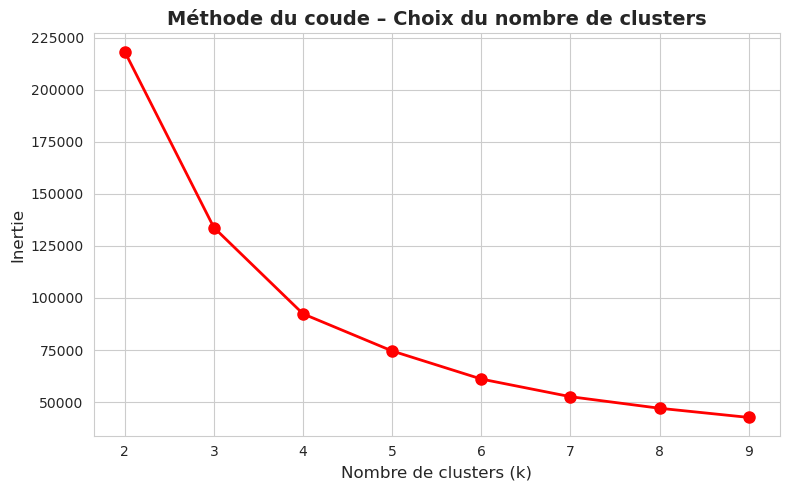

In [65]:
# 3. Méthode du coude (Elbow Method)

# On teste différentes valeurs de k (nombre de clusters) et on mesure l'inertie pour chaque k.
# L'inertie mesure la somme des distances entre chaque point et le centre de son cluster :  plus elle est faible, mieux c'est.
# On choisit le k à partir duquel l'inertie ne diminue plus
# significativement : c'est le "coude" de la courbe.

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="red", linewidth=2, markersize=8)
plt.title("Méthode du coude – Choix du nombre de clusters", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de clusters (k)", fontsize=12)
plt.ylabel("Inertie", fontsize=12)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Méthode du coude – Choix de k

La courbe montre une forte diminution de l'inertie entre k=2 et k=4, 
puis un aplatissement progressif à partir de k=4. 

On choisit **k=4** comme nombre optimal de clusters : au-delà, 
le gain en inertie ne justifie pas la complexité supplémentaire 
(trade-off biais-variance).

In [66]:
# 4. Entraînement K-Means avec k=4

# k=4 a été choisi grâce à la méthode du coude :
# c'est le point à partir duquel l'inertie ne diminue plus
# significativement.

K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_cluster["cluster"] = km_final.fit_predict(X_scaled)

# -------------------------------------------------------
# 5. Profils moyens par cluster
# -------------------------------------------------------
# On calcule la moyenne de chaque variable par cluster
# pour comprendre et nommer chaque profil type

profils = df_cluster.groupby("cluster")[cluster_features].mean().round(2)
print("=== Profils moyens par cluster ===")
print(profils)

=== Profils moyens par cluster ===
         trip_distance  duree_course  heure_journee  total_amount
cluster                                                          
0                 5.11         23.06          20.57         24.53
1                13.67         37.15          17.85         52.64
2                 1.61         11.21           8.26         11.39
3                 1.54          9.11          21.70         10.70


## Analyse des clusters – Profils types

### Cluster 0 – Le navetteur du soir
- Distance moyenne : 5.11 miles
- Durée moyenne : 23 minutes
- Heure moyenne : 20h57 (soirée)
- Montant moyen : 24.53$

Trajets moyens effectués en soirée, probablement des personnes 
rentrant chez elles après le travail ou une sortie.

### Cluster 1 – Le trajet aéroport
- Distance moyenne : 13.67 miles
- Durée moyenne : 37 minutes
- Heure moyenne : 17h85 (fin d'après-midi)
- Montant moyen : 52.64$

Longs trajets coûteux, cohérents avec les trajets vers JFK (~52$) 
ou Newark. C'est le cluster le plus rare mais le plus rentable 
pour les chauffeurs.

### Cluster 2 – Le court trajet matinal
- Distance moyenne : 1.61 miles
- Durée moyenne : 11 minutes
- Heure moyenne : 8h26 (matin)
- Montant moyen : 11.39$

Courts trajets le matin, typiques des new-yorkais se rendant 
au travail depuis leur quartier.

### Cluster 3 – Le court trajet nocturne
- Distance moyenne : 1.54 miles
- Durée moyenne : 9 minutes
- Heure moyenne : 21h70 (nuit)
- Montant moyen : 10.70$

Très courts trajets la nuit, probablement des sorties 
(restaurants, bars) dans Manhattan.

### Conclusion
Le K-Means a identifié 4 profils cohérents avec la réalité 
de NYC : trajets courts le matin, courts la nuit, moyens le soir 
et longs vers les aéroports. Ces segments peuvent aider les 
chauffeurs à optimiser leurs revenus en ciblant les créneaux 
les plus rentables.

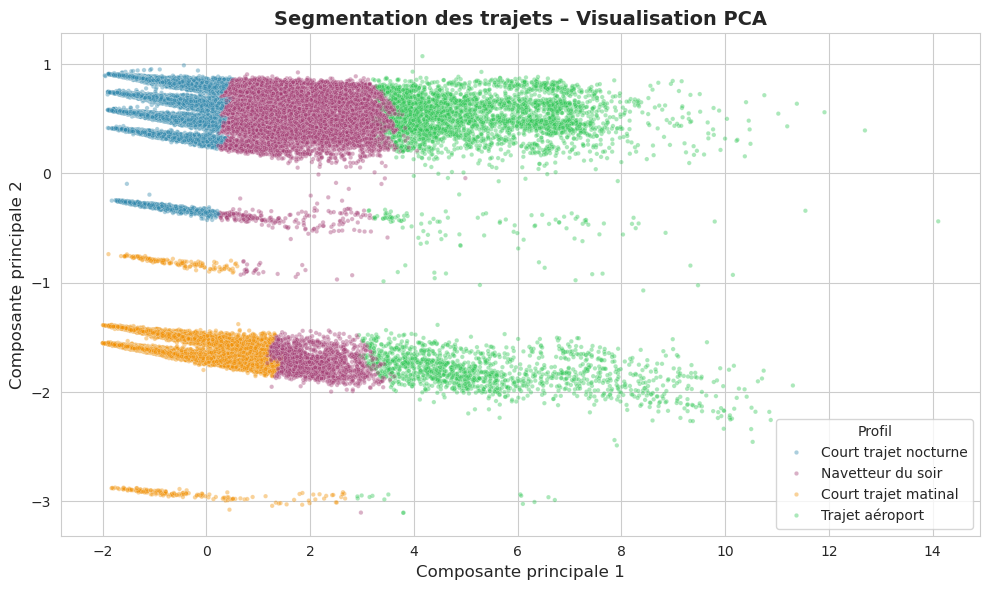

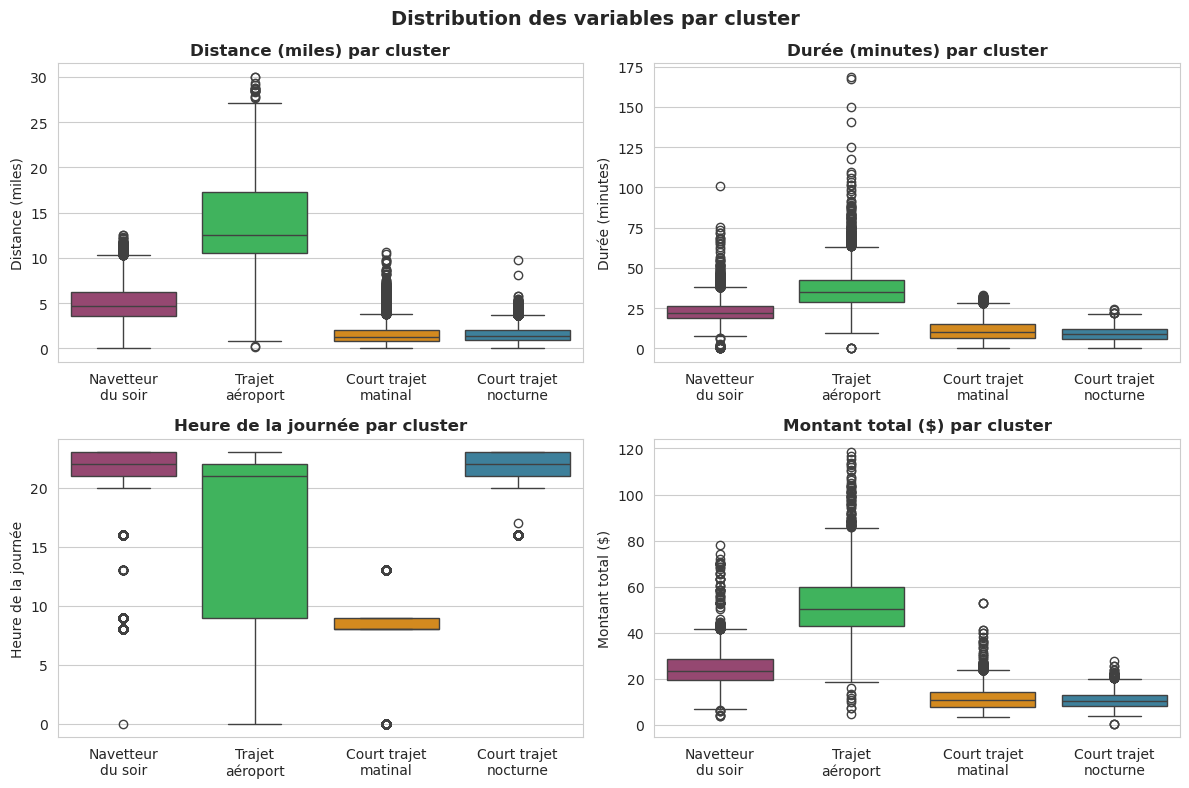

In [69]:
from sklearn.decomposition import PCA


# 6. Visualisation PCA – Réduction en 2D

# On ne peut pas visualiser 4 dimensions simultanément.La PCA réduit les 4 variables en 2 composantes principales
# qui capturent le maximum de variance possible,
# permettant d'afficher les clusters sur un graphe 2D.

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(coords, columns=["PC1", "PC2"])
df_pca["cluster"] = df_cluster["cluster"].values

# Noms des clusters pour la légende
cluster_names = {
    0: "Navetteur du soir",
    1: "Trajet aéroport",
    2: "Court trajet matinal",
    3: "Court trajet nocturne"
}
df_pca["profil"] = df_pca["cluster"].map(cluster_names)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1", y="PC2",
    hue="profil",
    palette=["#2E86AB", "#A23B72", "#F18F01", "#2DC653"],
    alpha=0.4,
    s=10
)
plt.title("Segmentation des trajets – Visualisation PCA", fontsize=14, fontweight="bold")
plt.xlabel("Composante principale 1", fontsize=12)
plt.ylabel("Composante principale 2", fontsize=12)
plt.legend(title="Profil", fontsize=10)
plt.tight_layout()
plt.show()


# 7. Boxplots – Distribution des variables par cluster

# On visualise la distribution de chaque variable pour chaque cluster pour confirmer que les clusters sont bien distincts

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables = {
    "trip_distance": "Distance (miles)",
    "duree_course": "Durée (minutes)",
    "heure_journee": "Heure de la journée",
    "total_amount": "Montant total ($)"
}

colors = ["#2E86AB", "#A23B72", "#F18F01", "#2DC653"]

for i, (col, label) in enumerate(variables.items()):
    ax = axes[i // 2][i % 2]
    
    # Ajout d'une colonne temporaire avec les noms des clusters
    df_cluster["profil"] = df_cluster["cluster"].map({
        0: "Navetteur\ndu soir",
        1: "Trajet\naéroport",
        2: "Court trajet\nmatinal",
        3: "Court trajet\nnocturne"
    })
    
    sns.boxplot(
        data=df_cluster,
        x="profil",                              # ← nom au lieu du numéro
        y=col,
        hue="profil",                            # ← corriger le warning palette
        palette=colors,
        legend=False,                            # ← pas de légende en double
        ax=ax,
        order=[                                  # ← ordre fixe des clusters
            "Navetteur\ndu soir",
            "Trajet\naéroport",
            "Court trajet\nmatinal",
            "Court trajet\nnocturne"
        ]
    )
    ax.set_title(f"{label} par cluster", fontsize=12, fontweight="bold")
    ax.set_xlabel("", fontsize=10)               # ← plus besoin du label x
    ax.set_ylabel(label, fontsize=10)

plt.suptitle("Distribution des variables par cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analyse des visualisations du clustering

### PCA – Segmentation en 2D

Le graphe montre 4 groupes bien distincts dans l'espace réduit.
Les clusters "Court trajet matinal" (orange) et "Court trajet nocturne" (bleu) sont très resserrés à gauche, ce qui confirme leur similarité en termes de distance et montant. Le cluster 
"Trajet aéroport" (vert) s'étale vers la droite grâce à ses longues distances, bien séparé des autres.

### Boxplots

**Distance et Montant** confirment parfaitement les profils :
le cluster "Trajet aéroport" est très séparé des trois autres avec une distance médiane de ~13 miles et un montant médian de ~52$. C'est aussi le cluster le plus variable, ce qui s'explique par les différentes destinations (JFK, Newark, LaGuardia).

**Heure de la journée** distingue clairement les trajets matinaux 
(Court trajet matinal autour de 8h-9h) des trajets nocturnes 
(Navetteur du soir et Court trajet nocturne concentrés autour de 21h-22h). Le Trajet aéroport est le plus dispersé sur 
la journée : les vols partent à toute heure.

**Durée** confirme que le Trajet aéroport est le plus long et le plus variable avec une médiane de ~35 minutes et des valeurs extrêmes jusqu'à 170 minutes en cas d'embouteillages.

### Conclusion générale du clustering

Le K-Means avec k=4 a identifié 4 profils cohérents avec la réalité de New York City. Ces segments sont exploitables concrètement : un chauffeur souhaitant maximiser ses revenus  devrait cibler les trajets aéroport (montant moyen 52$) 

plutôt que les courts trajets nocturnes (montant moyen 10$).

## Conclusion générale

Ce projet nous a permis de mener un pipeline complet de Data Science 
sur les données des taxis jaunes de New York City, des données brutes 
jusqu'aux modèles de Machine Learning.

### Ce que nous avons appris

**Exploration et nettoyage :** Le jeu de données contenait de nombreuses 
valeurs aberrantes (distances nulles, montants négatifs, coordonnées GPS 
hors NYC). Un nettoyage rigoureux basé sur les percentiles a permis 
de conserver 97 758 trajets valides sur 99 999 initiaux.

**Feature Engineering :** La création de variables dérivées 
(duree_course, est_weekend, est_heure_pointe, encodage cyclique) 
a enrichi l'information disponible pour les modèles, même si 
l'analyse d'importance a montré que la distance reste 
la variable dominante.

**Apprentissage supervisé :** Les deux modèles testés donnent 
d'excellents résultats (R² > 0.93), ce qui confirme que le prix 
d'un taxi à NYC est très bien expliqué par la distance et la durée. 
Le Random Forest améliore légèrement la régression linéaire 
(RMSE 2.64$ vs 2.75$) grâce à sa capacité à capturer 
des relations non linéaires.

**Apprentissage non supervisé :** Le K-Means a identifié 4 profils 
de trajets cohérents avec la réalité de NYC : courts trajets matinaux, 
courts trajets nocturnes, navetteurs du soir et trajets aéroport. 
Ces segments sont directement exploitables par les chauffeurs 
pour optimiser leurs revenus.

### Limites et perspectives

- L'analyse se limite à un mois de données (février 2016). 
  Une analyse sur une année complète permettrait de capturer 
  la saisonnalité.
- Le tip_amount n'a pas été analysé (uniquement disponible 
  pour les paiements par carte).
- Des modèles plus avancés (XGBoost, réseaux de neurones) 
  pourraient encore améliorer les performances.